
# How well do jobs and skills pay for Data Analysts?

### Methology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for data analysts
3. Visualize for highest paying skills and most demanded skills

In [17]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [18]:
df_CH = df[(df['job_country'] == 'Switzerland')].dropna(subset=['salary_year_avg'])

In [19]:
job_titles = df_CH['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Engineer',
 'Data Analyst',
 'Machine Learning Engineer',
 'Senior Data Scientist',
 'Software Engineer']

In [20]:
df_CH_top6 = df_CH[df_CH['job_title_short'].isin(job_titles)]

In [21]:
job_order = df_CH_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

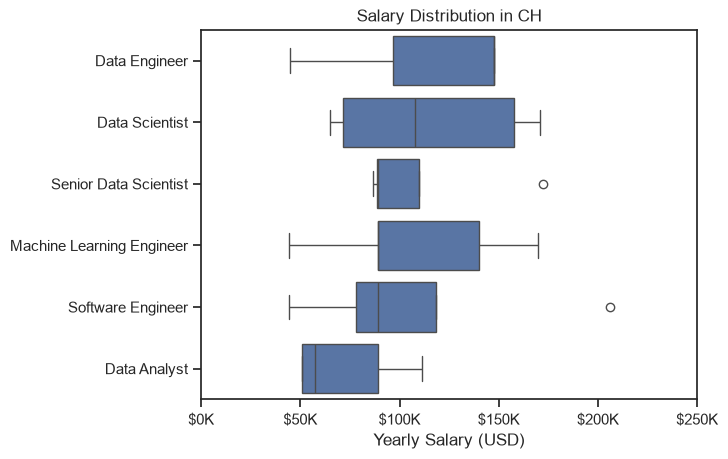

In [23]:
sns.boxplot(data=df_CH_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style="ticks")

plt.title('Salary Distribution in CH')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim([0,250000])
ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()